# Exact versus the textbook approximations

The selling point of this library is that it is exact. This notebook is the case for caring: where the familiar approximations agree with the exact answer, and where they do not.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

## The two-flavor vacuum formula is not an approximation

Worth establishing first, because it sets the baseline. In vacuum with two flavors, $P_{e\mu} = \sin^2 2\theta \, \sin^2(\Delta m^2 L/4E)$ is *exact*, and the SU(2) expansion reproduces it to round-off.

In [2]:
s12 = np.sqrt(0.310)
H2 = np.asarray(hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(
    s12, gd.D21_NO_BF))/(1.0*GEV)
L_km = np.logspace(0.0, 5.0, 4000)

exact = oscprob2nu.probabilities_2nu(H2, L_km*KM)[:, 1]
textbook = (4.0*s12**2.0*(1.0-s12**2.0)
            * np.sin(gd.D21_NO_BF*L_km*KM/(4.0*GEV))**2.0)

print("max |exact - textbook| = %.2e" % np.max(np.abs(
    exact-textbook)))

max |exact - textbook| = 1.55e-15


## Three flavors in vacuum: still exact

`hamiltonians3nu.probabilities_3nu_vacuum_std` evaluates the standard sum over mass eigenstates. In vacuum this is also exact, and the two agree — which is what makes it a useful cross-check of the SU(3) machinery rather than a competitor to it.

In [3]:
U = hamiltonians3nu.pmns_mixing_matrix(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF)

E_gev = np.logspace(-1.0, 1.5, 300)
L = 1300.0*KM

exact = oscprob3nu.probabilities_3nu(
    np.asarray(H_VAC_3NU)/(E_gev[:, None, None]*GEV), L)
std = np.array([hamiltonians3nu.probabilities_3nu_vacuum_std(
    U, gd.D21_NO_BF, gd.D31_NO_BF, e*GEV, L) for e in E_gev])

print("max |exact - standard formula| = %.2e"
      % np.max(np.abs(exact-std)))

max |exact - standard formula| = 7.53e-14


## Where it does break: constant density for a varying profile

The approximation that actually costs you is replacing a varying density by a constant. Below, the exact PREM calculation against the common shortcut of using a single average density along the chord.

In [4]:
import earth

costhz = -0.9
widths, densities = earth.earth_slabs(costhz, n_slabs_per_segment=8)
mean_density = np.average(densities, weights=widths)
total_km = widths.sum()

print("chord           : %.0f km" % total_km)
print("mean density    : %.3f g/cm^3" % mean_density)
print("range along it  : %.3f to %.3f g/cm^3"
      % (densities.min(), densities.max()))

chord           : 11468 km
mean density    : 6.863 g/cm^3
range along it  : 1.020 to 10.866 g/cm^3


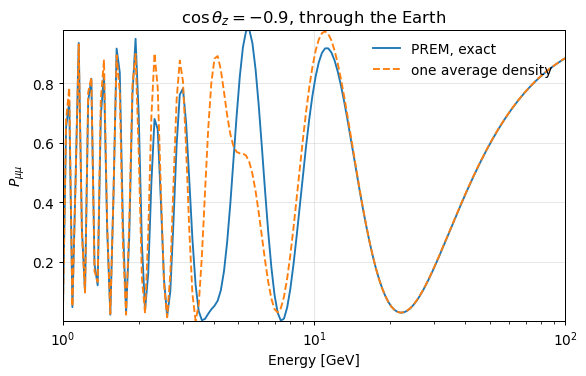

max difference : 0.833
mean difference: 0.086


In [5]:
E_gev = np.logspace(0.0, 2.0, 160)

p_prem, p_const = [], []
for e in E_gev:
    p_prem.append(earth.probabilities_3nu_earth(
        H_VAC_3NU, e*GEV, costhz, n_slabs_per_segment=8)[4])
    H = hamiltonians3nu.hamiltonian_3nu_matter(
        H_VAC_3NU, e*GEV, earth.matter_potential(mean_density))
    p_const.append(oscprob3nu.probabilities_3nu(
        H, total_km*KM)[4])
p_prem, p_const = np.array(p_prem), np.array(p_const)

fig, ax = plt.subplots()
ax.semilogx(E_gev, p_prem, label="PREM, exact")
ax.semilogx(E_gev, p_const, "--",
            label="one average density")
ax.set_xlim(E_gev[0], E_gev[-1])
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel(r"$P_{\mu\mu}$")
ax.set_title(r"$\cos\theta_z = -0.9$, through the Earth")
ax.legend()
plt.show()

print("max difference : %.3f" % np.max(np.abs(p_prem-p_const)))
print("mean difference: %.3f" % np.mean(np.abs(p_prem-p_const)))

## And the two-flavor reduction of a three-flavor problem

Appearance is often estimated with a two-flavor formula driven by the atmospheric parameters. Against the full three-flavor result that neglects the solar term and CP violation entirely.

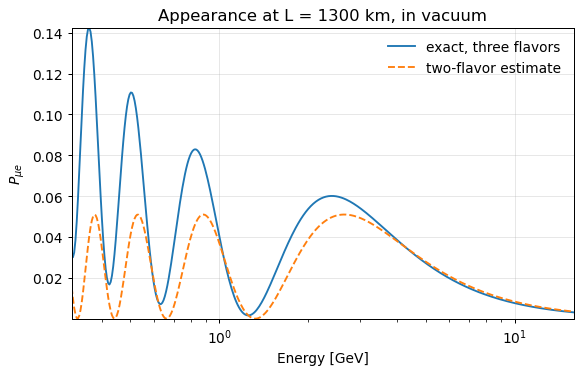

max difference near the first maximum: 0.0158


In [6]:
E_gev = np.logspace(-0.5, 1.2, 400)
L = 1300.0*KM

p3 = oscprob3nu.probabilities_3nu(
    np.asarray(H_VAC_3NU)/(E_gev[:, None, None]*GEV), L)[:, 3]

# The usual two-flavor estimate for nu_mu -> nu_e
sin2_2th13 = 4.0*gd.S13_NO_BF**2.0*(1.0-gd.S13_NO_BF**2.0)
s23sq = gd.S23_NO_BF**2.0
p2 = (s23sq*sin2_2th13
      * np.sin(gd.D31_NO_BF*L/(4.0*E_gev*GEV))**2.0)

fig, ax = plt.subplots()
ax.semilogx(E_gev, p3, label="exact, three flavors")
ax.semilogx(E_gev, p2, "--",
            label=r"two-flavor estimate")
ax.set_xlim(E_gev[0], E_gev[-1])
ax.set_xlabel("Energy [GeV]")
ax.set_ylabel(r"$P_{\mu e}$")
ax.set_title("Appearance at L = 1300 km, in vacuum")
ax.legend()
plt.show()

print("max difference near the first maximum: %.4f"
      % np.max(np.abs(p3-p2)[E_gev > 1.0]))

The gap is the solar term and the CP-violating interference — precisely the physics a long-baseline experiment is built to measure. An approximation that discards it is not a small error in the quantity of interest; it is the quantity of interest.

---

**Previous:** [The paper's figures](10_paper_figures.ipynb)  
**Next:** [Mass ordering and the octant](12_ordering_and_octant.ipynb) --- two open questions, and how they show up  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)